# Numpy

Материалы:
* Лекции
* https://numpy.org/doc/stable/user/index.html
* https://numpy.org/doc/stable/reference/index.html

## Задача

1. Сгенерировать двухмерный массив `arr` размерности (4, 7), состоящий из случайных действительных чисел, равномерно распределенных в диапазоне от 0 до 20. Нормализовать значения массива с помощью преобразования вида  $𝑎𝑥+𝑏$  так, что после нормализации максимальный элемент масcива будет равен 1.0, минимальный 0.0

In [2]:
import numpy as np

arr = np.random.uniform(0, 20, (4, 7))
xmin = arr.min()
xmax = arr.max()
arr_norm = (arr - xmin) / (xmax - xmin)

print('\nНормализованный массив:')
print(arr_norm)

print('\nМинимум после нормализации:', arr_norm.min())
print('\nМаксимум после нормализации:', arr_norm.max())



Нормализованный массив:
[[0.51701978 0.24836238 0.8265644  0.08795104 0.97628614 0.19543692
  0.51600687]
 [0.51705107 0.29855662 0.18763264 0.7368559  1.         0.25774562
  0.48745791]
 [0.68378881 0.55936014 0.3272395  0.15269569 0.12325789 0.49325744
  0.39906999]
 [0.97252828 0.62216757 0.23754292 0.81874935 0.         0.46976799
  0.60960524]]

Минимум после нормализации: 0.0

Максимум после нормализации: 1.0


## Лабораторная работа №1

Замечание: при решении данных задач не подразумевается использования циклов или генераторов Python, если в задании не сказано обратного. Решение должно опираться на использования функционала библиотеки `numpy`.

1. Файл `minutes_n_ingredients.csv` содержит информацию об идентификаторе рецепта, времени его выполнения в минутах и количестве необходимых ингредиентов. Считайте данные из этого файла в виде массива `numpy` типа `int32`, используя `np.loadtxt`. Выведите на экран первые 5 строк массива.

In [3]:
import numpy as np

data = np.loadtxt('minutes_n_ingredients.csv', delimiter=',', dtype=np.int32, skiprows=1)
print(data[0:5])

[[127244     60     16]
 [ 23891     25      7]
 [ 94746     10      6]
 [ 67660      5      6]
 [157911     60     14]]


2. Вычислите среднее значение, минимум, максимум и медиану по каждому из столбцов, кроме первого.

In [6]:
res1 = data[:, 1]
res2 = data[:, 2]
print('Ср. значение:', np.mean(res1), '\nминимум:', np.min(res1), '\nмаксимум:',  np.max(res1), '\nмедиана:',  np.median(res1))
print('---------------------')
print('Ср. значение:', np.mean(res2), '\nминимум:', np.min(res2), '\nмаксимум:',  np.max(res2), '\nмедиана:',  np.median(res2))

Ср. значение: 21601.00169 
минимум: 0 
максимум: 2147483647 
медиана: 40.0
---------------------
Ср. значение: 9.05528 
минимум: 1 
максимум: 39 
медиана: 9.0


3. Ограничьте сверху значения продолжительности выполнения рецепта значением квантиля $q_{0.75}$.

In [ ]:
minutes = data[:, 1]
k = np.quantile(minutes, 0.75)
res3 = np.clip(minutes, None, k)
print(res3)

4. Посчитайте, для скольких рецептов указана продолжительность, равная нулю. Замените для таких строк значение в данном столбце на 1.

In [9]:
cur = data[:, 1]
cnt = np.sum(cur == 0)
minutes[cur == 0] = 1
print(cnt)

479


5. Посчитайте, сколько уникальных рецептов находится в датасете.

In [10]:
uniq = np.unique(data[:, 0])
print(len(uniq))

100000


# Numpy

Материалы:
* Макрушин С.В. "Лекция 1: Библиотека Numpy"
* https://numpy.org/doc/stable/user/index.html
* https://numpy.org/doc/stable/reference/index.html

## Задача

2. Создать матрицу 8 на 10 из случайных целых (используя модуль `numpy.random`) чисел из диапазона от 0 до 10 и найти в ней строку (ее индекс и вывести саму строку), в которой сумма значений минимальна.

In [4]:
import numpy as np

s = np.random.randint(0, 11, size=(8, 10))
sums = np.sum(s, axis=1)
print(np.argmin(sums))

7


3. Найти евклидово расстояние между двумя одномерными векторами одинаковой размерности.

In [5]:
a = np.random.randint(1, 10, 5)
b = np.random.randint(1, 10, 5)

distance = np.linalg.norm(a - b)
print(distance)

8.306623862918075


Евклидово расстояние между двумя векторами 𝑎 a и 𝑏 b одинаковой размерности 𝑛 n вычисляется по формуле:

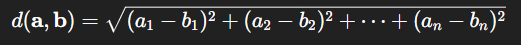

## Лабораторная работа №1

Замечание: при решении данных задач не подразумевается использования циклов или генераторов Python, если в задании не сказано обратного. Решение должно опираться на использования функционала библиотеки `numpy`.

6. Сколько и каких различных значений кол-ва ингредиентов присутвует в рецептах из датасета?

In [7]:
data = np.loadtxt('minutes_n_ingredients.csv', delimiter=',', dtype=np.int32, skiprows=1)
uniq = np.unique(data[:, 2])
print(len(uniq))
print(uniq)

37
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 37 39]


7. Создайте версию массива, содержащую информацию только о рецептах, состоящих не более чем из 5 ингредиентов.

In [10]:
msk = data[:, 2] <= 5
res = data[msk]
print(res)

[[446597     15      5]
 [204134      5      3]
 [ 25623      6      4]
 ...
 [ 52088     60      5]
 [128811     15      4]
 [370915      5      4]]


8. Для каждого рецепта посчитайте, сколько в среднем ингредиентов приходится на одну минуту рецепта. Найдите максимальное значение этой величины для всего датасета

In [16]:
mask = data[:, 1] != 0
new_data = data[mask]
rez = new_data[:, 2] / new_data[:, 1]
print(rez)
print(np.max(rez))

[0.26666667 0.28       0.6        ... 0.23076923 0.8        0.1       ]
23.0


9. Вычислите среднее количество ингредиентов для топ-100 рецептов с наибольшей продолжительностью

In [17]:
cur = np.argsort(data[:, 1])[::-1]
data_sorted = data[cur]
top = data_sorted[:100]
print(np.mean(top[:, 2]))

6.61


10. Выберите случайным образом и выведите информацию о 10 различных рецептах

In [18]:
from random import*
idx = np.random.choice(data.shape[0], size=10, replace=False)
print(data[idx])

[[393660     70     10]
 [172356     60     10]
 [257416     75     11]
 [380264     35      8]
 [ 27208    545      5]
 [509806     17      8]
 [213123    195     12]
 [ 85892     20      8]
 [447570     25      5]
 [215361    215      6]]


# Numpy

4. Решить матричное уравнение A*X*B=-C - найти матрицу X. Где A = [[-2, 1, 3], [-2, 4, 2], [-3, 0, 3]], B=[[3, -2], [2, 4]], C=[[7, 23], [11, 7], [8, 5]].

In [2]:
import numpy as np

A = np.array([[-2, 1, 3], [-2, 4, 2], [-3, 0, 3]])
B = np.array([[3, -2], [2, 4]])
C = np.array([[7, 23], [11, 7], [8, 5]])

X = -np.linalg.inv(A) @ C @ np.linalg.inv(B)
print(X)

[[ 2.73958333 -2.90104167]
 [-0.23958333 -0.34895833]
 [ 2.28125    -3.546875  ]]


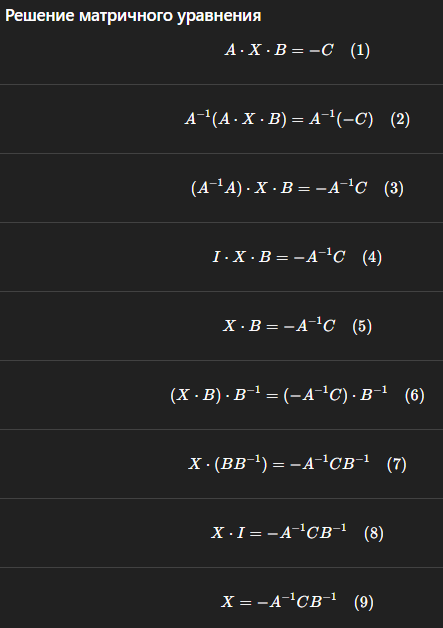

## Лабораторная работа №1

Замечание: при решении данных задач не подразумевается использования циклов или генераторов Python, если в задании не сказано обратного. Решение должно опираться на использования функционала библиотеки `numpy`.

11. Выведите процент рецептов, кол-во ингредиентов в которых меньше среднего.

In [7]:
import numpy as np

data = np.loadtxt('minutes_n_ingredients.csv', delimiter=',', dtype=np.int32, skiprows=1)

ing = data[:, 2]
mean_ing = ing.mean()
less = ing < mean_ing
percent = (less.sum() / len(data)) * 100
print(f"Процент рецептов с ингредиентами меньше среднего: {percent}%")

Процент рецептов с ингредиентами меньше среднего: 58.802%


12. Назовем "простым" такой рецепт, длительность выполнения которого не больше 20 минут и кол-во ингредиентов в котором не больше 5. Создайте версию датасета с дополнительным столбцом, значениями которого являются 1, если рецепт простой, и 0 в противном случае.

In [8]:
simple = (data[:, 1] <= 20) & (data[:, 2] <= 5)
simple_col = simple.astype(int)
data_new = np.column_stack((data, simple_col))
print(data_new)

[[127244     60     16      0]
 [ 23891     25      7      0]
 [ 94746     10      6      0]
 ...
 [498432     65     15      0]
 [370915      5      4      1]
 [ 81993    140     14      0]]


13. Выведите процент "простых" рецептов в датасете

In [9]:
simple_percent = (simple.sum() / len(data)) * 100
print(f"Процент простых рецептов: {simple_percent}%")

Процент простых рецептов: 9.552%


14. Разделим рецепты на группы по следующему правилу. Назовем рецепты короткими, если их продолжительность составляет менее 10 минут; стандартными, если их продолжительность составляет более 10, но менее 20 минут; и длинными, если их продолжительность составляет не менее 20 минут. Создайте трехмерный массив, где нулевая ось отвечает за номер группы (короткий, стандартный или длинный рецепт), первая ось - за сам рецепт и вторая ось - за характеристики рецепта. Выберите максимальное количество рецептов из каждой группы таким образом, чтобы было возможно сформировать трехмерный массив. Выведите форму полученного массива.

In [10]:
minutes = data[:, 1]
short = data[minutes < 10]
standard = data[(minutes > 10) & (minutes < 20)]
long = data[minutes >= 20]

n = min(len(short), len(standard), len(long))
result = np.array([short[:n], standard[:n], long[:n]])

print(f"Форма массива: {result.shape}")

Форма массива: (3, 7588, 3)


## Лабораторная работа №2

### Базовые операции с `DataFrame`

1.1 В файлах `recipes_sample.csv` и `reviews_sample.csv` находится информация об рецептах блюд и отзывах на эти рецепты соответственно. Загрузите данные из файлов в виде `pd.DataFrame` с названиями `recipes` и `reviews`. Обратите внимание на корректное считывание столбца с индексами в таблице `reviews` (безымянный столбец).

In [3]:
import pandas as pd
import numpy as np

recipes = pd.read_csv('recipes_sample.csv')
reviews = pd.read_csv('reviews_sample.csv', index_col=0)


1.2 Для каждой из таблиц выведите основные параметры:
* количество точек данных (строк);
* количество столбцов;
* тип данных каждого столбца.

In [5]:
print("=== RECIPES ===")
print("Количество строк:", recipes.shape[0])
print("Количество столбцов:", recipes.shape[1])
print("\nТипы данных столбцов:")
print(recipes.dtypes)
print("\n")

print("=== REVIEWS ===")
print("Количество строк:", reviews.shape[0])
print("Количество столбцов:", reviews.shape[1])
print("\nТипы данных столбцов:")
print(reviews.dtypes)

=== RECIPES ===
Количество строк: 30000
Количество столбцов: 8

Типы данных столбцов:
name                  str
id                  int64
minutes             int64
contributor_id      int64
submitted             str
n_steps           float64
description           str
n_ingredients     float64
dtype: object


=== REVIEWS ===
Количество строк: 126696
Количество столбцов: 5

Типы данных столбцов:
user_id      int64
recipe_id    int64
date           str
rating       int64
review         str
dtype: object


1.3 Исследуйте, в каких столбцах таблиц содержатся пропуски. Посчитайте долю строк, содержащих пропуски, в отношении к общему количеству строк.

In [6]:
print("=== ПРОПУСКИ В RECIPES ===")
print("Количество пропусков по столбцам:")
print(recipes.isnull().sum())

# Доля строк с хотя бы одним пропуском
null_rows_ratio = recipes.isnull().any(axis=1).mean()
print(f"Доля строк с пропусками: {null_rows_ratio:.2%}\n")

print("=== ПРОПУСКИ В REVIEWS ===")
print("Количество пропусков по столбцам:")
print(reviews.isnull().sum())

null_rows_ratio_rev = reviews.isnull().any(axis=1).mean()
print(f"Доля строк с пропусками: {null_rows_ratio_rev:.2%}")

=== ПРОПУСКИ В RECIPES ===
Количество пропусков по столбцам:
name                  0
id                    0
minutes               0
contributor_id        0
submitted             0
n_steps           11190
description         623
n_ingredients      8880
dtype: int64
Доля строк с пропусками: 56.85%

=== ПРОПУСКИ В REVIEWS ===
Количество пропусков по столбцам:
user_id       0
recipe_id     0
date          0
rating        0
review       17
dtype: int64
Доля строк с пропусками: 0.01%


1.4 Рассчитайте среднее значение для каждого из числовых столбцов (где это имеет смысл).

In [8]:
print("=== RECIPES ===")
numeric_cols = recipes.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    mean_val = recipes[col].mean()
    print(f"{col}: {mean_val:.2f}")

print("=== REVIEWS ===")
numeric_cols = reviews.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    mean_val = reviews[col].mean()
    print(f"{col}: {mean_val:.2f}")

=== RECIPES ===
id: 221879.29
minutes: 123.36
contributor_id: 5635900.57
n_steps: 9.81
n_ingredients: 9.01
=== REVIEWS ===
user_id: 140801264.74
recipe_id: 160094.39
rating: 4.41


1.5 Создайте серию из 10 случайных названий рецептов.

In [14]:
random_names = recipes['name'].dropna().sample(10).tolist()

for i, name in enumerate(random_names, 1):
    print(f"{i}. {name}")

1. pomegranate chipotle bbq sauce
2. plums poached in marsala
3. cornmeal apple cake
4. decadent caramel chocolate cheesecake
5. lemon cheese souffle with lemon ginger sauce
6. chicago italian roast beef sandwich
7. whole grain mustard dip
8. lacy lou s hot sauce
9. au gratin crock pot potatoes
10. skinny bride s guide to layered vegetable salad


1.6 Измените индекс в таблице `reviews`, пронумеровав строки, начиная с нуля.

In [16]:
reviews = reviews.reset_index(drop=True)

print("Первые 5 строк с новым индексом:")
print(reviews.head())
print(f"Индекс начинается с: {reviews.index[0]}")

Первые 5 строк с новым индексом:
      user_id  recipe_id        date  rating  \
0       21752      57993  2003-05-01       5   
1      431813     142201  2007-09-16       5   
2      400708     252013  2008-01-10       4   
3  2001852463     404716  2017-12-11       5   
4       95810     129396  2008-03-14       5   

                                              review  
0  Last week whole sides of frozen salmon fillet ...  
1  So simple and so tasty!  I used a yellow capsi...  
2  Very nice breakfast HH, easy to make and yummy...  
3  These are a favorite for the holidays and so e...  
4  Excellent soup!  The tomato flavor is just gre...  
Индекс начинается с: 0


1.7 Выведите информацию о рецептах, время выполнения которых не больше 20 минут и кол-во ингредиентов в которых не больше 5.

In [17]:
time_condition = recipes['minutes'] <= 20
ingredients_condition = recipes['n_ingredients'] <= 5

filtered_recipes = recipes[time_condition & ingredients_condition]

print(f"Найдено рецептов: {len(filtered_recipes)}")
print("\nСписок рецептов:")
print(filtered_recipes[['name', 'minutes', 'n_ingredients']].to_string(index=False))

Найдено рецептов: 2019

Список рецептов:
                                                            name  minutes  n_ingredients
                                             quick biscuit bread       20            5.0
                                   peas  fit for a king or queen       20            5.0
                               hawaiian sunrise           mimosa        5            3.0
                      tasty dish s   banana pudding in 2 minutes        2            4.0
                                              1 minute meatballs       13            2.0
                                              10 minute lime pie       10            5.0
                                          100 year old pie crust       15            5.0
                                       1000 island vegetable dip       20            2.0
                                               2 minute broccoli        4            2.0
                                                   3 fruit salad     

### Работа с датами в `pandas`

2.1 Преобразуйте столбец `submitted` из таблицы `recipes` в формат времени. Модифицируйте решение задачи 1.1 так, чтобы считать столбец сразу в нужном формате.

In [18]:
recipes['submitted'] = pd.to_datetime(recipes['submitted'])
print(recipes)

                                               name      id  minutes  \
0             george s at the cove  black bean soup   44123       90   
1                healthy for them  yogurt popsicles   67664       10   
2                      i can t believe it s spinach   38798       30   
3                              italian  gut busters   35173       45   
4          love is in the air  beef fondue   sauces   84797       25   
...                                             ...     ...      ...   
29995  zurie s holey rustic olive and cheddar bread  267661       80   
29996          zwetschgenkuchen  bavarian plum cake  386977      240   
29997   zwiebelkuchen   southwest german onion cake  103312       75   
29998                                   zydeco soup  486161       60   
29999        cookies by design   cookies on a stick  298512       29   

       contributor_id  submitted  n_steps  \
0               35193 2002-10-25      NaN   
1               91970 2003-07-26      NaN   


2.2 Выведите информацию о рецептах, добавленных в датасет не позже 2010 года.

In [19]:
recipes_2010 = recipes[recipes['submitted'].dt.year <= 2010]

print(recipes_2010[['name', 'submitted', 'minutes']])

                                               name  submitted  minutes
0             george s at the cove  black bean soup 2002-10-25       90
1                healthy for them  yogurt popsicles 2003-07-26       10
2                      i can t believe it s spinach 2002-08-29       30
3                              italian  gut busters 2002-07-27       45
4          love is in the air  beef fondue   sauces 2004-02-23       25
...                                             ...        ...      ...
29993                     zuni caf zucchini pickles 2008-07-31     2895
29995  zurie s holey rustic olive and cheddar bread 2007-11-25       80
29996          zwetschgenkuchen  bavarian plum cake 2009-08-24      240
29997   zwiebelkuchen   southwest german onion cake 2004-11-03       75
29999        cookies by design   cookies on a stick 2008-04-15       29

[27661 rows x 3 columns]


### Работа со строковыми данными в `pandas`

3.1  Добавьте в таблицу `recipes` столбец `description_length`, в котором хранится длина описания рецепта из столбца `description`.

In [ ]:
recipes['description_length'] = recipes['description'].str.len()

In [ ]:
'''3.2 Измените название каждого рецепта в таблице `recipes` таким образом, чтобы каждое слово в названии начиналось с прописной буквы.'''

recipes['name'] = recipes['name'].str.title()

3.3 Добавьте в таблицу `recipes` столбец `name_word_count`, в котором хранится количество слов из названии рецепта (считайте, что слова в названии разделяются только пробелами). Обратите внимание, что между словами может располагаться несколько пробелов подряд.

In [ ]:
'''3.3 Добавьте в таблицу `recipes` столбец `name_word_count`, в котором хранится количество слов из названии рецепта (считайте, что слова в названии разделяются только пробелами). Обратите внимание, что между словами может располагаться несколько пробелов подряд.'''

recipes['name_word_count'] = recipes['name'].str.split().str.len()

### Группировки таблиц `pd.DataFrame`

4.1 Посчитайте количество рецептов, представленных каждым из участников (`contributor_id`). Какой участник добавил максимальное кол-во рецептов?

In [20]:
recipes_by_contributor = recipes.groupby('contributor_id').size().sort_values(ascending=False)

print("Количество рецептов по участникам")
print("Первые 10 участников с наибольшим количеством рецептов:")
print(recipes_by_contributor.head(10))

max_contributor = recipes_by_contributor.index[0]
max_count = recipes_by_contributor.iloc[0]

print(f"\nУчастник с максимальным количеством рецептов: {max_contributor}")
print(f"Количество рецептов: {max_count}")

=== Количество рецептов по участникам ===
Первые 10 участников с наибольшим количеством рецептов:
contributor_id
89831     421
37449     346
37779     345
1533      186
169430    183
58104     180
80353     147
4470      141
283251    127
166642    115
dtype: int64

Участник с максимальным количеством рецептов: 89831
Количество рецептов: 421


4.2 Посчитайте средний рейтинг к каждому из рецептов. Для скольких рецептов отсутствуют отзывы? Обратите внимание, что отзыв с нулевым рейтингом или не заполненным текстовым описанием не считается отсутствующим.

In [22]:
avg_rating_by_recipe = reviews.groupby('recipe_id')['rating'].mean().reset_index()
avg_rating_by_recipe.columns = ['recipe_id', 'avg_rating']

print("=== Средний рейтинг по рецептам ===\n")
print("Первые 10 рецептов со средним рейтингом:")
print(avg_rating_by_recipe.head(10))

# Находим рецепты, на которые нет отзывов
recipes_without_reviews = set(recipes['id']) - set(reviews['recipe_id'])
print(f"\nКоличество рецептов без отзывов: {len(recipes_without_reviews)}")

# Проверка: рецепты, у которых есть отзывы, но рейтинг 0
# Это не считается отсутствием отзыва
recipes_with_zero_rating = reviews[reviews['rating'] == 0]['recipe_id'].nunique()
print(f"Рецепты с отзывом и рейтингом 0: {recipes_with_zero_rating}")

=== Средний рейтинг по рецептам ===

Первые 10 рецептов со средним рейтингом:
   recipe_id  avg_rating
0         48    1.000000
1         55    4.750000
2         66    4.944444
3         91    4.750000
4         94    5.000000
5        128    5.000000
6        148    0.000000
7        153    3.923077
8        176    5.000000
9        181    2.666667

Количество рецептов без отзывов: 1900
Рецепты с отзывом и рейтингом 0: 3990


4.3 Посчитайте количество рецептов с разбивкой по годам создания.

In [21]:
# Извлекаем год из столбца submitted и считаем количество рецептов по годам
recipes_by_year = recipes['submitted'].dt.year.value_counts().sort_index()

print("=== Количество рецептов по годам ===\n")
print(recipes_by_year)

# Для наглядности в виде таблицы
print("\nВ виде таблицы:")
recipes_by_year_df = recipes_by_year.reset_index()
recipes_by_year_df.columns = ['Год', 'Количество рецептов']
print(recipes_by_year_df.to_string(index=False))

=== Количество рецептов по годам ===

submitted
1999     275
2000     104
2001     589
2002    2644
2003    2334
2004    2153
2005    3130
2006    3473
2007    4429
2008    4029
2009    2963
2010    1538
2011     922
2012     659
2013     490
2014     139
2015      42
2016      24
2017      39
2018      24
Name: count, dtype: int64

В виде таблицы:
 Год  Количество рецептов
1999                  275
2000                  104
2001                  589
2002                 2644
2003                 2334
2004                 2153
2005                 3130
2006                 3473
2007                 4429
2008                 4029
2009                 2963
2010                 1538
2011                  922
2012                  659
2013                  490
2014                  139
2015                   42
2016                   24
2017                   39
2018                   24


### Объединение таблиц `pd.DataFrame`

5.1 При помощи объединения таблиц, создайте `DataFrame`, состоящий из четырех столбцов: `id`, `name`, `user_id`, `rating`. Рецепты, на которые не оставлен ни один отзыв, должны отсутствовать в полученной таблице. Подтвердите правильность работы вашего кода, выбрав рецепт, не имеющий отзывов, и попытавшись найти строку, соответствующую этому рецепту, в полученном `DataFrame`.

In [28]:
result_5_1 = recipes[['id', 'name']].merge(
    reviews[['recipe_id', 'user_id', 'rating']],
    left_on='id',
    right_on='recipe_id',
    how='inner'
).drop('recipe_id', axis=1)

print(f"Количество строк: {len(result_5_1)}")
print(f"Столбцы: {result_5_1.columns.tolist()}")
print("\nПервые 5 строк:")
print(result_5_1.head())

recipes_without_reviews = set(recipes['id']) - set(reviews['recipe_id'])
if recipes_without_reviews:
    test_recipe = list(recipes_without_reviews)[0]
    test_name = recipes[recipes['id'] == test_recipe]['name'].iloc[0]

    print(f"\n=== Проверка ===")
    print(f"Рецепт без отзывов: ID={test_recipe}, Название={test_name}")

    found = result_5_1[result_5_1['id'] == test_recipe]
    if found.empty:
        print("Результат: рецепт отсутствует в таблице (верно)")
    else:
        print("Результат: рецепт ЕСТЬ в таблице (ошибка!)")

Количество строк: 126696
Столбцы: ['id', 'name', 'user_id', 'rating']

Первые 5 строк:
      id                                   name  user_id  rating
0  44123  george s at the cove  black bean soup   743566       5
1  44123  george s at the cove  black bean soup    76503       5
2  44123  george s at the cove  black bean soup    34206       5
3  67664     healthy for them  yogurt popsicles   494084       5
4  67664     healthy for them  yogurt popsicles   303445       5

=== Проверка ===
Рецепт без отзывов: ID=401411, Название=crunchy ranch croutons
Результат: рецепт отсутствует в таблице (верно)


5.2 При помощи объединения таблиц и группировок, создайте `DataFrame`, состоящий из трех столбцов: `recipe_id`, `name`, `review_count`, где столбец `review_count` содержит кол-во отзывов, оставленных на рецепт `recipe_id`. У рецептов, на которые не оставлен ни один отзыв, в столбце `review_count` должен быть указан 0. Подтвердите правильность работы вашего кода, выбрав рецепт, не имеющий отзывов, и найдя строку, соответствующую этому рецепту, в полученном `DataFrame`.

In [ ]:
review_counts = reviews.groupby('recipe_id').size().reset_index(name='review_count')

result_5_2 = recipes[['id', 'name']].merge(
    review_counts,
    left_on='id',
    right_on='recipe_id',
    how='left'
).drop('recipe_id', axis=1)

result_5_2['review_count'] = result_5_2['review_count'].fillna(0).astype(int)

print("\n=== Количество отзывов по рецептам ===\n")
print(f"Количество строк: {len(result_5_2)}")
print(f"Столбцы: {result_5_2.columns.tolist()}")
print("\nПервые 10 строк:")
print(result_5_2.head(10))

if recipes_without_reviews:
    test_recipe = list(recipes_without_reviews)[0]
    test_row = result_5_2[result_5_2['id'] == test_recipe]

    print(f"\n=== Проверка ===")
    print(f"Рецепт без отзывов: ID={test_recipe}")
    print(f"Количество отзывов: {test_row['review_count'].iloc[0]}")
    print("Результат: 0 (верно)" if test_row['review_count'].iloc[0] == 0 else "Результат: не 0 (ошибка!)")

5.3. Выясните, рецепты, добавленные в каком году, имеют наименьший средний рейтинг?

In [ ]:
recipes_with_ratings = recipes[['id', 'submitted']].merge(
    reviews[['recipe_id', 'rating']],
    left_on='id',
    right_on='recipe_id',
    how='inner'
)

avg_rating_by_year = recipes_with_ratings.groupby(
    recipes_with_ratings['submitted'].dt.year
)['rating'].mean().sort_values()

print("\n=== 5.3 Средний рейтинг по годам ===\n")
print(avg_rating_by_year)

min_year = avg_rating_by_year.idxmin()
min_rating = avg_rating_by_year.min()

print(f"\nГод с наименьшим средним рейтингом: {min_year}")
print(f"Средний рейтинг: {min_rating:.2f}")

### Сохранение таблиц `pd.DataFrame`

6.1 Отсортируйте таблицу в порядке убывания величины столбца `name_word_count` и сохраните результаты выполнения заданий 3.1-3.3 в csv файл.

In [29]:
results_3 = recipes[['name', 'description_length', 'name_word_count']].copy()

results_3_sorted = results_3.sort_values('name_word_count', ascending=False)

results_3_sorted.to_csv('recipes_with_text_stats.csv', index=False)

print("=== 6.1 Сохранение в CSV ===\n")
print(f"Сохранено {len(results_3_sorted)} строк в файл 'recipes_with_text_stats.csv'")
print("Столбцы:", results_3_sorted.columns.tolist())
print("\nПервые 5 строк (отсортировано по количеству слов):")
print(results_3_sorted.head())

KeyError: "['description_length', 'name_word_count'] not in index"

6.2 Воспользовавшись `pd.ExcelWriter`, cохраните результаты 5.1 и 5.2 в файл: на лист с названием `Рецепты с оценками` сохраните результаты выполнения 5.1; на лист с названием `Количество отзывов по рецептам` сохраните результаты выполнения 5.2.

In [26]:
with pd.ExcelWriter('recipes_analysis.xlsx') as writer:
    result.to_excel(writer, sheet_name='Рецепты с оценками', index=False)
    result_5_2.to_excel(writer, sheet_name='Количество отзывов по рецептам', index=False)

print(f"  - {len(result)} строк, столбцы: {result.columns.tolist()}")
print("Лист 2: 'Количество отзывов по рецептам' (результат 5.2)")
print(f"  - {len(result_5_2)} строк, столбцы: {result_5_2.columns.tolist()}")

ModuleNotFoundError: No module named 'openpyxl'